# Assessment Task 2 - Part A

## EXPERIMENT 4: SSD - YOLO - RF-DETR CHOICE

The following Experiment adapts the content from the [ Week9-Part-1-Object detection-YOLOv5-AWS.ipynb ] lab notes.

# Step 1: Clone github repository

#### **Clone the GitHub Repository (Default Location: /root/)**

In [1]:
# By Default Cloned under root
!git clone https://github.com/ultralytics/yolov5

fatal: destination path 'yolov5' already exists and is not an empty directory.


#### **Install the required libraries**

In [2]:
%cd yolov5
#from yolov5 import utils
#display = utils.notebook_init()  # checks Pytorch and GPU used
!pip install -r requirements.txt

/home/sagemaker-user/42028-DL-CNN-2026/Assessment Task 2/yolov5
  Using cached thop-0.1.1.post2209072238-py3-none-any.whl.metadata (2.7 kB)
  Using cached urllib3-2.6.3-py3-none-any.whl.metadata (6.9 kB)
  Using cached polars-1.40.1-py3-none-any.whl.metadata (10 kB)
  Using cached ultralytics_thop-2.0.19-py3-none-any.whl.metadata (14 kB)
  Using cached polars_runtime_32-1.40.1-cp310-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (1.5 kB)
Using cached urllib3-2.6.3-py3-none-any.whl (131 kB)
Using cached thop-0.1.1.post2209072238-py3-none-any.whl (15 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 61.1 MB/s  0:00:00
Using cached polars-1.40.1-py3-none-any.whl (828 kB)
Using cached polars_runtime_32-1.40.1-cp310-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (56.3 MB)
Using cached ultralytics_thop-2.0.19-py3-none-any.whl (28 kB)
  Attempting uninstall: urllib3
    Found existing installation: urllib3 1.26.20
    Uninstalling urllib3-1.26.20:
      Successfull

# Step 2: Setup Training Configuration

In [3]:
#@title Setup Training YAML File
number_of_classes = 5 #@param {type:"integer"}
with open('new_train_yaml', 'w+') as file:
    file.write(
        f"""
        # parameters
        nc: {number_of_classes}  # number of classes
        depth_multiple: 0.33  # model depth multiple
        width_multiple: 0.50  # layer channel multiple

        # anchors
        anchors:
          - [10,13, 16,30, 33,23]  # P3/8
          - [30,61, 62,45, 59,119]  # P4/16
          - [116,90, 156,198, 373,326]  # P5/32

        # YOLOv5 backbone
        backbone:
          # [from, number, module, args]
          [[-1, 1, Focus, [64, 3]],  # 0-P1/2
           [-1, 1, Conv, [128, 3, 2]],  # 1-P2/4
           [-1, 3, BottleneckCSP, [128]],
           [-1, 1, Conv, [256, 3, 2]],  # 3-P3/8
           [-1, 9, BottleneckCSP, [256]],
           [-1, 1, Conv, [512, 3, 2]],  # 5-P4/16
           [-1, 9, BottleneckCSP, [512]],
           [-1, 1, Conv, [1024, 3, 2]],  # 7-P5/32
           [-1, 1, SPP, [1024, [5, 9, 13]]],
           [-1, 3, BottleneckCSP, [1024, False]],  # 9
          ]

        # YOLOv5 head
        head:
          [[-1, 1, Conv, [512, 1, 1]],
           [-1, 1, nn.Upsample, [None, 2, 'nearest']],
           [[-1, 6], 1, Concat, [1]],  # cat backbone P4
           [-1, 3, BottleneckCSP, [512, False]],  # 13

           [-1, 1, Conv, [256, 1, 1]],
           [-1, 1, nn.Upsample, [None, 2, 'nearest']],
           [[-1, 4], 1, Concat, [1]],  # cat backbone P3
           [-1, 3, BottleneckCSP, [256, False]],  # 17 (P3/8-small)

           [-1, 1, Conv, [256, 3, 2]],
           [[-1, 14], 1, Concat, [1]],  # cat head P4
           [-1, 3, BottleneckCSP, [512, False]],  # 20 (P4/16-medium)

           [-1, 1, Conv, [512, 3, 2]],
           [[-1, 10], 1, Concat, [1]],  # cat head P5
           [-1, 3, BottleneckCSP, [1024, False]],  # 23 (P5/32-large)

           [[17, 20, 23], 1, Detect, [nc, anchors]],  # Detect(P3, P4, P5)
          ]
        """
    )

# Step 3: Setup Dataset paths

In [4]:
#@title Setup Dataset Configuration (Data.yaml)
train_data_dir = "../25349642/Object_Detection/yolo/train" #@param {type:"string"}
val_data_dir = "../25349642/Object_Detection/yolo/valid" #@param {type:"string"}
class_names = ['boat', 'car', 'dock', 'jetski', 'lift'] #@param {type:"raw"}


In [5]:
!pwd
!cd ..

/home/sagemaker-user/42028-DL-CNN-2026/Assessment Task 2/yolov5


In [6]:
!ls

CITATION.cff	 benchmarks.py	models		  tests
CONTRIBUTING.md  classify	new_train_yaml	  train.py
LICENSE		 data		pyproject.toml	  tutorial.ipynb
README.md	 detect.py	requirements.txt  utils
README.zh-CN.md  export.py	runs		  val.py
__pycache__	 hubconf.py	segment		  yolov5s.pt


# Step 4: Start Training

In [ ]:
## ENTER CODE TO START TRAINING ##
!python train.py --img 416 --batch 16 --epochs 300 --data "/home/sagemaker-user/42028-DL-CNN-2026/Assessment Task 2/25349642/Object_Detection/yolo/data.yaml" --weights yolov5s.pt --seed 25349642


2026-05-07 11:18:36.676215: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778152716.705438    6344 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778152716.716557    6344 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
train: weights=yolov5s.pt, cfg=, data=/home/sagemaker-user/42028-DL-CNN-2026/Assessment Task 2/25349642/Object_Detection/yolo/data.yaml, hyp=data/hyps/hyp.scratch-low.yaml, epochs=300, batch_size=16, imgsz=416, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, evolve_population=data/hyps, resume_evolve=None, bucket=, cache=None, image_weights=False, device=, multi_scale=False, single

# Step 5: Display result images

In [ ]:
%cd /home/sagemaker-user/42028-DL-CNN-2026/Assessment Task 2/yolov5

/home/sagemaker-user/42028-DL-CNN-2026/Assessment Task 2/yolov5


In [ ]:
import cv2
from matplotlib import pyplot as plt
from PIL import Image

# This is needed to display the images.
%matplotlib inline

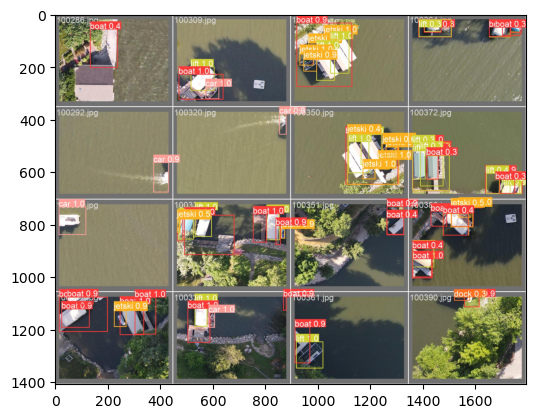

In [ ]:
image = Image.open('runs/train/exp8/val_batch1_pred.jpg')
plt.imshow(image)

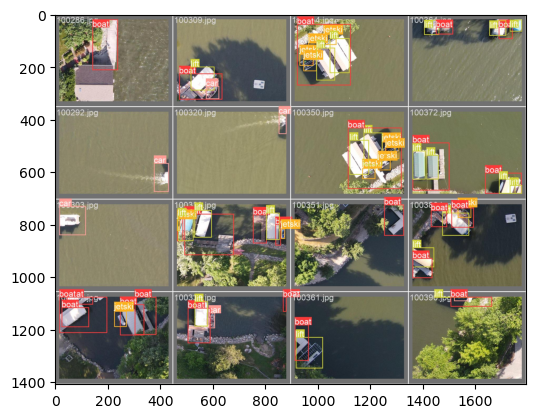

In [ ]:
image = Image.open('runs/train/exp8/val_batch1_labels.jpg')
plt.imshow(image)

# Step 6: Display performance analysis

In [ ]:
#check the current directory
!pwd

/home/sagemaker-user/42028-DL-CNN-2026/Assessment Task 2/yolov5


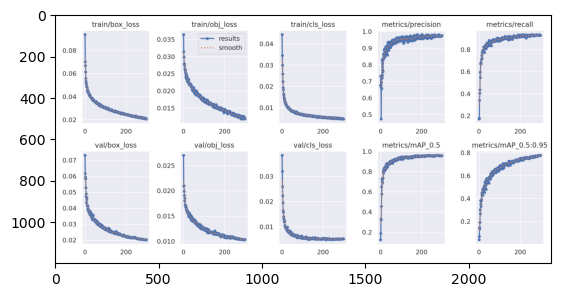

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
image = Image.open('runs/train/exp8/results.png')
# ^ Change 'exp' to the last in the train directory ^
plt.imshow(image)